## **Airline Passenger Satisfaction Classification Project ✈️**

# Part 2: Classification Model Building and Evaluation

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import ConfusionMatrixDisplay 



from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

**1 Load Data**

In [20]:
air = pd.read_csv("data/cleaned_airline_passenger_satisfaction.csv")

air.head()

,id,gender,customer_type,age,type_of_travel,class,flight_distance,inflight_wifi_service,departure_arrival_time_convenient,ease_of_online_booking,...,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25.0,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1.0,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0.0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11.0,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0.0,0.0,satisfied


**2. Data Preparation**

**Define Target Variable and Features**

satisfaction

In [21]:
air.columns = air.columns.str.strip()

In [22]:
X = air.drop("satisfaction", axis=1)
y = air["satisfaction"]

X = pd.get_dummies(X, drop_first=True)

**3. Train/Test Split**

8/20

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
print(X_train.shape)
print(X_test.shape)

(83123, 24)
(20781, 24)


**4. Standard Scaling**

In [25]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Instantiate KNN

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=9)

**5. Model Fitting and Evaluation**

In [27]:
knn.fit(X_train_sc, y_train)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [28]:
knn.score(X_train_sc, y_train)

0.9395353873175896

In [29]:
knn.score(X_test_sc, y_test)

0.9284442519609258

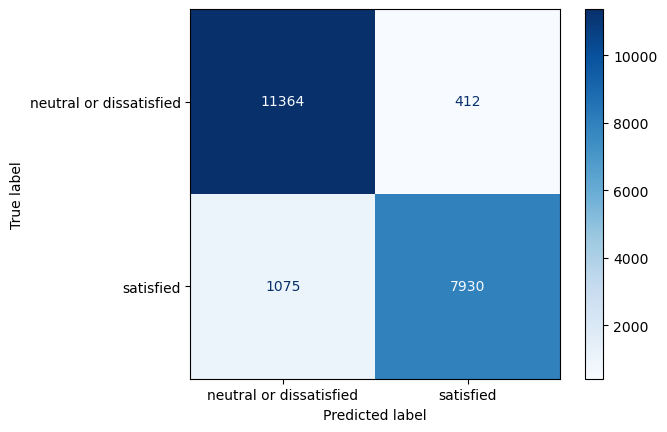

In [30]:
ConfusionMatrixDisplay.from_estimator(knn, X_test_sc, y_test, cmap = 'Blues')

Test multiple values of K for KNN

In [31]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

scores = []

for k in range(3, 32, 2):
    
    knn = KNeighborsClassifier(n_neighbors=k)
    
    knn.fit(X_train_sc, y_train)
    
    train_score = knn.score(X_train_sc, y_train)
    test_score = knn.score(X_test_sc, y_test)

    scores.append({
        'k': k,
        'train_score': train_score,
        'test_score': test_score
    })
air_score = pd.DataFrame(scores)

air_score

,k,train_score,test_score
0,3,0.956691,0.925124
1,5,0.946802,0.927530
2,7,0.942363,0.928300
3,9,0.939535,0.928444
4,11,0.937033,0.928204
5,13,0.935397,0.928637
6,15,0.934374,0.927819
7,17,0.933111,0.927386
8,19,0.932004,0.927626
9,21,0.930477,0.927193


Visualize the result

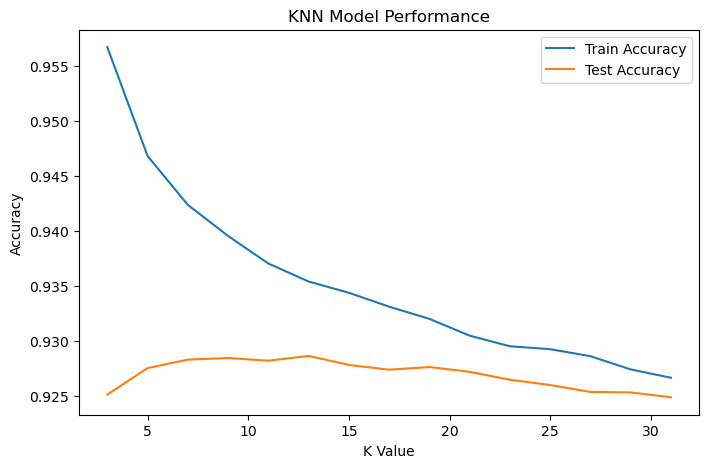

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(air_score['k'], air_score['train_score'], label='Train Accuracy')
plt.plot(air_score['k'], air_score['test_score'], label='Test Accuracy')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Model Performance")

plt.legend()
plt.show()

**6. Train Logistic Regression Model**

In [33]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train_sc, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Evaluate Logistic Regression Model

In [55]:
lr.score(X_train_sc, y_train)

0.8758947583701262

In [49]:
lr.score(X_test_sc, y_test)

0.8781098118473606

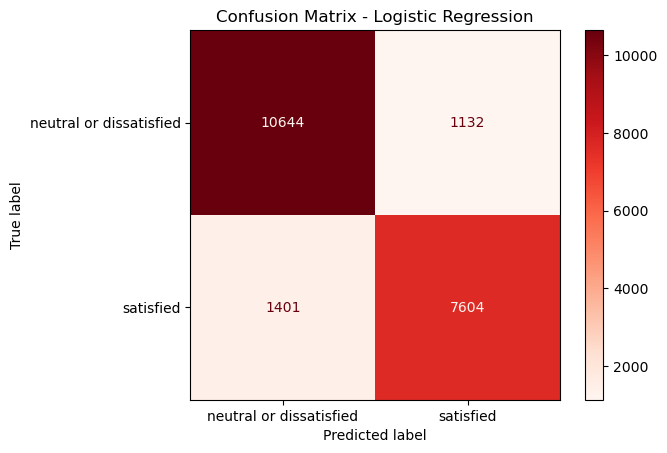

In [50]:
ConfusionMatrixDisplay.from_estimator(
    lr,
    X_test_sc,
    y_test,
    cmap='Reds')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**7. Random Forest Model**

In [58]:
rf = RandomForestClassifier()
rf.fit(X_train_sc, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [59]:
rf.score(X_train_sc, y_train)

1.0

In [62]:
rf.score(X_test_sc, y_test)

0.964198065540638

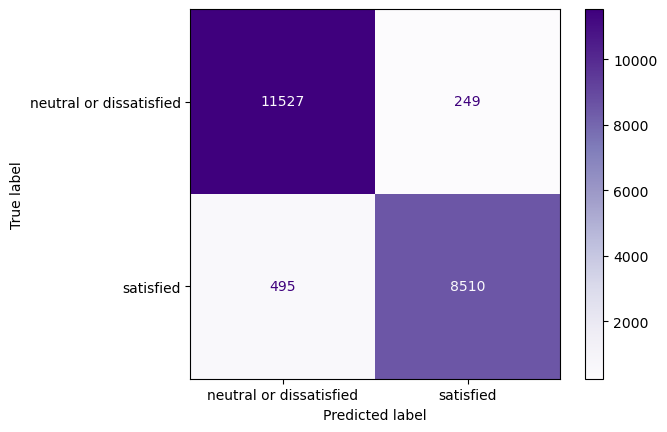

In [63]:
ConfusionMatrixDisplay.from_estimator(rf, X_test_sc, y_test, cmap = 'Purples');

**8. Feature Importance**

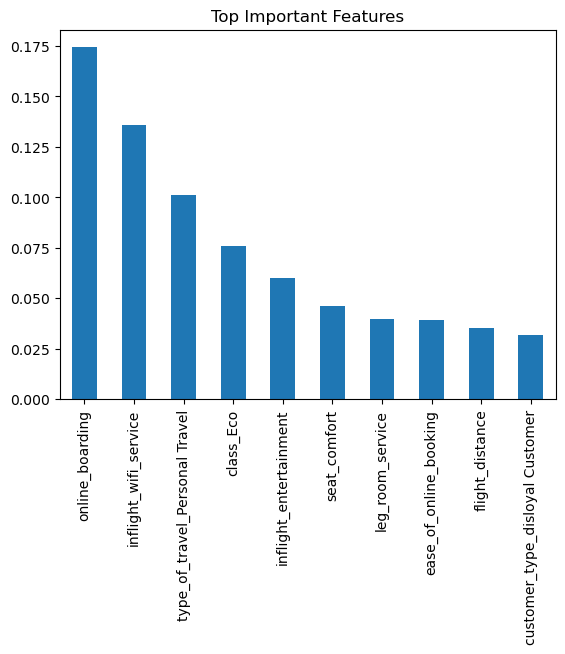

In [64]:
importances = rf.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)

feature_importance.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Important Features")
plt.show()

In [65]:
import joblib

joblib.dump(rf, "model.joblib")

['model.joblib']

In [67]:
joblib.dump(lr, "model.joblib")

['model.joblib']

**Conclusion/Model Results Section**

Several classification models were trained to predict airline passenger satisfaction, including Logistic Regression, K-Nearest Neighbors (KNN), and Random Forest. The Logistic Regression model achieved an accuracy of approximately 87.8%, providing a solid baseline for predicting passenger satisfaction.

The KNN model improved the performance, reaching a testing accuracy of around 92.8% when using optimal values of k. This indicates that passenger satisfaction patterns can be captured effectively by considering similarities between observations.

The Random Forest model performed the best, achieving an accuracy of approximately 96.4%. This suggests that ensemble tree-based methods are particularly effective for this dataset because they can capture complex relationships between service quality, travel characteristics, and delays.

Overall, the results indicate that service-related features and travel experience factors are strong predictors of passenger satisfaction, and the Random Forest model provides the most reliable predictions among the models tested.